In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import random

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("Downloads/filtered_datasetf-Copy1.csv")
df

,COUNTRYNAME,Gender,Age,age_mh,Education,Household_Income,Subjective_Income,EMP_2010,Global11Regions,WorldBank_Income_Group,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,United States,2,80,,2,5,2,6,9,4,...,4,5,3,3,3,2,5,1,4,2
1,United States,1,23,,3,4,1,1,9,4,...,2,2,3,4,2,2,3,1,1,4
2,United States,1,29,,3,4,1,1,9,4,...,5,1,1,2,5,2,5,1,3,4
3,United States,2,60,,3,4,2,1,9,4,...,4,4,2,2,2,5,3,1,1,1
4,United States,1,41,,2,2,4,6,9,4,...,3,2,5,1,3,3,4,1,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119083,Kosovo,2,27,,3,0,1,1,2,3,...,1,5,1,3,1,4,3,2,4,4
119084,Kosovo,2,24,2,3,0,2,6,2,3,...,1,1,4,4,3,2,4,1,5,2
119085,Kosovo,1,24,,3,0,1,2,2,3,...,4,3,2,1,1,1,3,2,5,2
119086,Kosovo,1,29,,3,0,2,1,2,3,...,5,2,3,5,5,2,1,2,5,3


In [ ]:
df.head()

,COUNTRYNAME,Gender,Age,age_mh,Education,Household_Income,Subjective_Income,EMP_2010,Global11Regions,WorldBank_Income_Group,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,United States,2,80,,2,5,2,6,9,4,...,4,5,3,3,3,2,5,1,4,2
1,United States,1,23,,3,4,1,1,9,4,...,2,2,3,4,2,2,3,1,1,4
2,United States,1,29,,3,4,1,1,9,4,...,5,1,1,2,5,2,5,1,3,4
3,United States,2,60,,3,4,2,1,9,4,...,4,4,2,2,2,5,3,1,1,1
4,United States,1,41,,2,2,4,6,9,4,...,3,2,5,1,3,3,4,1,4,3


In [ ]:
df.tail()

,COUNTRYNAME,Gender,Age,age_mh,Education,Household_Income,Subjective_Income,EMP_2010,Global11Regions,WorldBank_Income_Group,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
119083,Kosovo,2,27,,3,0,1,1,2,3,...,1,5,1,3,1,4,3,2,4,4
119084,Kosovo,2,24,2,3,0,2,6,2,3,...,1,1,4,4,3,2,4,1,5,2
119085,Kosovo,1,24,,3,0,1,2,2,3,...,4,3,2,1,1,1,3,2,5,2
119086,Kosovo,1,29,,3,0,2,1,2,3,...,5,2,3,5,5,2,1,2,5,3
119087,Kosovo,1,30,,3,0,2,1,2,3,...,3,3,4,5,2,2,1,3,4,2


# DATASET STRUCTURE


In [ ]:
print("Shape:", df.shape)

Shape: (119088, 36)


In [ ]:
print("Columns:\n", df.columns.to_list())

Columns:
 ['COUNTRYNAME', 'Gender', 'Age', 'age_mh', 'Education', 'Household_Income', 'Subjective_Income', 'EMP_2010', 'Global11Regions', 'WorldBank_Income_Group', 'sci_helps(human b works)', 'sci_helps(feel&emo)', 'sci_helps(anxiety&depr)', 'sci_helps(infec. Dis)', 'sci_helps(obessity)', 'GovtFundResearch(depr)', 'Community_Comfort_Speaking', 'Family_Friends_Experienced_MH', 'Self_Experienced_MH', 'Self_MH_More_Than_Once', 'Used_Mental_Health_Professional', 'Used_Religious_Support', 'Used_Family_or_Friends', 'Used_Prescribed_Medication', 'Used_Healthy_Lifestyle_Changes', 'Used_Work_Change', 'Used_Personal_Relationship_Change', 'Used_Nature_or_Outdoors', 'Is_Helpful_Mental_Health_Professional', 'Is_Helpful_Religious_Support', 'Is_Helpful_Family_or_Friends', 'Is_Helpful_Prescribed_Medication', 'Is_Helpful_Healthy_Lifestyle_Changes', 'Is_Helpful_Work_Change', 'Is_Helpful_Personal_Relationship_Change', 'Is_Helpful_Nature_or_Outdoors']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119088 entries, 0 to 119087
Data columns (total 36 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   COUNTRYNAME                              119088 non-null  object
 1   Gender                                   119088 non-null  int64 
 2   Age                                      119088 non-null  int64 
 3   age_mh                                   119088 non-null  object
 4   Education                                119088 non-null  int64 
 5   Household_Income                         119088 non-null  int64 
 6   Subjective_Income                        119088 non-null  int64 
 7   EMP_2010                                 119088 non-null  object
 8   Global11Regions                          119088 non-null  int64 
 9   WorldBank_Income_Group                   119088 non-null  int64 
 10  sci_helps(human b works)                 119

# SUMMARY STATISTICS

In [ ]:
df.describe()

,Gender,Age,Education,Household_Income,Subjective_Income,Global11Regions,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
count,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,...,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000,119088.000000
mean,1.490108,40.121994,2.788047,0.903701,2.223960,5.961776,2.974271,8.680136,11.499664,2.962406,...,3.004207,2.993064,3.002813,2.999387,2.998085,3.003443,2.996112,3.002536,3.002082,3.002662
std,0.499904,17.302497,7.660811,1.642699,1.039213,3.703928,0.923089,25.391834,28.762529,13.816900,...,1.415718,1.416439,1.416083,1.416222,1.414604,1.412647,1.415570,1.411727,1.416324,1.411837
min,1.000000,15.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,26.000000,2.000000,0.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,1.000000,36.000000,2.000000,0.000000,2.000000,6.000000,3.000000,1.000000,2.000000,1.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,2.000000,52.000000,3.000000,1.000000,3.000000,10.000000,4.000000,2.000000,3.000000,2.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,2.000000,100.000000,99.000000,5.000000,6.000000,11.000000,4.000000,99.000000,99.000000,99.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# CHECK FOR DUPLICATE VALUES

In [ ]:
df.duplicated().sum()

0

# CHECK FOR MISING VALUES

In [ ]:
df.isna().sum().sum()

0

# HANDLING NULL VALUES

In [ ]:
df.isnull()

,COUNTRYNAME,Gender,Age,age_mh,Education,Household_Income,Subjective_Income,EMP_2010,Global11Regions,WorldBank_Income_Group,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119083,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
119084,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
119085,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
119086,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# MAKING DATA SHORTER

In [ ]:
unique_countries = df['COUNTRYNAME'].dropna().unique()
unique_countries
df['COUNTRYNAME'].value_counts().head(15)

COUNTRYNAME
China              3502
India              3045
Russia             2002
Israel             1063
Lebanon            1035
Uganda             1027
Montenegro         1027
Senegal            1025
Indonesia          1023
Chile              1021
Algeria            1020
North Macedonia    1019
Estonia            1013
Saudi Arabia       1013
Cyprus             1012
Name: count, dtype: int64

In [ ]:
df1 = df[df['COUNTRYNAME'].isin(['China', 'India', 'Russia', 'Israel', 'Lebanon','Uganda','Montenegro','Senegal','Indonesia','Chile','Algeria','North Macedonia','Estonia','Saudi Arabia','Cyprus'])]
df1

,COUNTRYNAME,Gender,Age,age_mh,Education,Household_Income,Subjective_Income,EMP_2010,Global11Regions,WorldBank_Income_Group,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
3017,Lebanon,2,62,,3,5,3,6,10,3,...,3,3,3,1,4,5,2,1,1,5
3018,Lebanon,1,44,,2,2,3,6,10,3,...,5,4,1,5,2,2,4,4,3,3
3019,Lebanon,2,38,,3,5,2,6,10,3,...,1,2,5,1,4,2,3,4,1,5
3020,Lebanon,1,62,,1,3,3,6,10,3,...,5,1,4,3,1,4,5,4,4,3
3021,Lebanon,1,25,,3,5,2,5,10,3,...,3,5,1,1,5,5,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102051,Montenegro,2,32,,1,0,1,6,2,3,...,3,4,2,2,5,1,5,2,3,3
102052,Montenegro,1,67,5,2,0,3,6,2,3,...,1,4,2,3,4,1,3,3,2,2
102053,Montenegro,2,27,,3,0,1,1,2,3,...,2,5,4,5,3,3,4,1,3,3
102054,Montenegro,2,38,,2,0,2,6,2,3,...,5,3,4,1,3,4,4,5,4,1


In [ ]:
# UNNECESSARY COLUMNS FOR EXPLORATION
df1 = df1.drop(['Education','EMP_2010','Global11Regions','age_mh'], axis=1)

In [ ]:
df1

,COUNTRYNAME,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
3017,Lebanon,2,62,5,3,3,1,2,2,1,...,3,3,3,1,4,5,2,1,1,5
3018,Lebanon,1,44,2,3,3,4,99,99,4,...,5,4,1,5,2,2,4,4,3,3
3019,Lebanon,2,38,5,2,3,1,2,3,1,...,1,2,5,1,4,2,3,4,1,5
3020,Lebanon,1,62,3,3,3,3,4,1,1,...,5,1,4,3,1,4,5,4,4,3
3021,Lebanon,1,25,5,2,3,1,1,2,1,...,3,5,1,1,5,5,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102051,Montenegro,2,32,0,1,3,1,2,0,0,...,3,4,2,2,5,1,5,2,3,3
102052,Montenegro,1,67,0,3,3,2,3,0,0,...,1,4,2,3,4,1,3,3,2,2
102053,Montenegro,2,27,0,1,3,1,1,0,0,...,2,5,4,5,3,3,4,1,3,3
102054,Montenegro,2,38,0,2,3,1,2,0,0,...,5,3,4,1,3,4,4,5,4,1


In [ ]:
df1.reset_index(drop=True, inplace=True)
df1

,COUNTRYNAME,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,Lebanon,2,62,5,3,3,1,2,2,1,...,3,3,3,1,4,5,2,1,1,5
1,Lebanon,1,44,2,3,3,4,99,99,4,...,5,4,1,5,2,2,4,4,3,3
2,Lebanon,2,38,5,2,3,1,2,3,1,...,1,2,5,1,4,2,3,4,1,5
3,Lebanon,1,62,3,3,3,3,4,1,1,...,5,1,4,3,1,4,5,4,4,3
4,Lebanon,1,25,5,2,3,1,1,2,1,...,3,5,1,1,5,5,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20842,Montenegro,2,32,0,1,3,1,2,0,0,...,3,4,2,2,5,1,5,2,3,3
20843,Montenegro,1,67,0,3,3,2,3,0,0,...,1,4,2,3,4,1,3,3,2,2
20844,Montenegro,2,27,0,1,3,1,1,0,0,...,2,5,4,5,3,3,4,1,3,3
20845,Montenegro,2,38,0,2,3,1,2,0,0,...,5,3,4,1,3,4,4,5,4,1


In [ ]:
df1.shape

(20847, 32)

# SUMMARY STATISTICS

In [ ]:
df1.describe()

,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),sci_helps(obessity),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
count,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,...,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000
mean,1.448650,37.716554,1.538783,2.251595,2.903008,8.539694,11.321773,3.928335,3.473593,4.120641,...,2.985370,2.984170,2.993764,3.002398,3.005133,3.003694,3.005612,3.009642,3.008107,3.003166
std,0.497368,16.103489,1.917271,1.020216,0.823125,25.242965,28.630212,16.335045,15.679975,16.776770,...,1.414833,1.421602,1.411687,1.416008,1.418218,1.414192,1.420616,1.413485,1.413597,1.409215
min,1.000000,15.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,25.000000,0.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,1.000000,34.000000,0.000000,2.000000,3.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,2.000000,47.000000,3.000000,3.000000,3.000000,2.000000,3.000000,2.000000,1.000000,2.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,2.000000,100.000000,5.000000,6.000000,4.000000,99.000000,99.000000,99.000000,99.000000,99.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20847 entries, 0 to 20846
Data columns (total 32 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   COUNTRYNAME                              20847 non-null  object
 1   Gender                                   20847 non-null  int64 
 2   Age                                      20847 non-null  int64 
 3   Household_Income                         20847 non-null  int64 
 4   Subjective_Income                        20847 non-null  int64 
 5   WorldBank_Income_Group                   20847 non-null  int64 
 6   sci_helps(human b works)                 20847 non-null  int64 
 7   sci_helps(feel&emo)                      20847 non-null  int64 
 8   sci_helps(anxiety&depr)                  20847 non-null  int64 
 9   sci_helps(infec. Dis)                    20847 non-null  int64 
 10  sci_helps(obessity)                      20847 non-null  i

In [ ]:
# Replace empty strings with NaN
df1['GovtFundResearch(depr)'] = df1['GovtFundResearch(depr)'].replace('', np.nan)
# Fill NaN values (example: fill with 0)
df1['GovtFundResearch(depr)'] = df1['GovtFundResearch(depr)'].fillna(0)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20847 entries, 0 to 20846
Data columns (total 32 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   COUNTRYNAME                              20847 non-null  object
 1   Gender                                   20847 non-null  int64 
 2   Age                                      20847 non-null  int64 
 3   Household_Income                         20847 non-null  int64 
 4   Subjective_Income                        20847 non-null  int64 
 5   WorldBank_Income_Group                   20847 non-null  int64 
 6   sci_helps(human b works)                 20847 non-null  int64 
 7   sci_helps(feel&emo)                      20847 non-null  int64 
 8   sci_helps(anxiety&depr)                  20847 non-null  int64 
 9   sci_helps(infec. Dis)                    20847 non-null  int64 
 10  sci_helps(obessity)                      20847 non-null  i

# EXPLORE CATEGORICAL COLUMNS

In [ ]:
df1['Gender'] = df1['Gender'].replace({1:'Male',2:'Female'})

df1.head()

,COUNTRYNAME,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,Lebanon,Female,62,5,3,3,1,2,2,1,...,3,3,3,1,4,5,2,1,1,5
1,Lebanon,Male,44,2,3,3,4,99,99,4,...,5,4,1,5,2,2,4,4,3,3
2,Lebanon,Female,38,5,2,3,1,2,3,1,...,1,2,5,1,4,2,3,4,1,5
3,Lebanon,Male,62,3,3,3,3,4,1,1,...,5,1,4,3,1,4,5,4,4,3
4,Lebanon,Male,25,5,2,3,1,1,2,1,...,3,5,1,1,5,5,2,1,2,1


In [ ]:
print(df1.Gender.value_counts())

Gender
Male      11494
Female     9353
Name: count, dtype: int64


In [ ]:
income_mapping = {
    1: 'Poorest 20%',
    2: 'Second 20%',
    3: 'Middle 20%',
    4: 'Fourth 20%',
    5: 'Richest 20%',
    0: 'Not Disclosed/Lowest'}

df1['Household_Income'] = df1['Household_Income'].replace(income_mapping)


In [ ]:
print(df1['Household_Income'].value_counts())

Household_Income
Not Disclosed/Lowest    11229
Richest 20%              2701
Fourth 20%               2159
Middle 20%               1812
Second 20%               1556
Poorest 20%              1390
Name: count, dtype: int64


In [ ]:
print(df1.COUNTRYNAME.value_counts())

COUNTRYNAME
China              3502
India              3045
Russia             2002
Israel             1063
Lebanon            1035
Uganda             1027
Montenegro         1027
Senegal            1025
Indonesia          1023
Chile              1021
Algeria            1020
North Macedonia    1019
Saudi Arabia       1013
Estonia            1013
Cyprus             1012
Name: count, dtype: int64


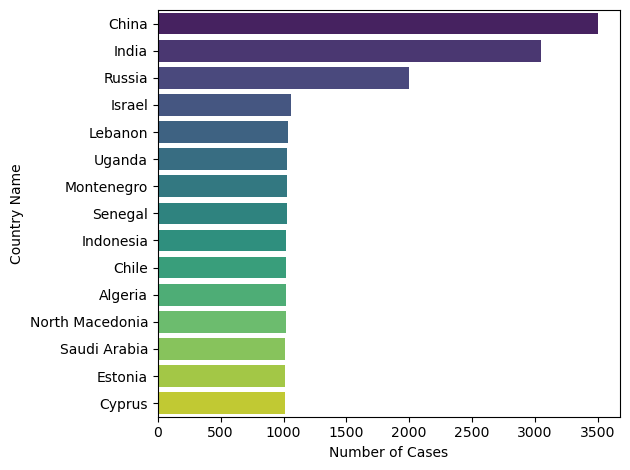

In [ ]:

# Count the number of 'cases' (Self_Experienced_MH == 1) per country
case_counts_by_country = df1['COUNTRYNAME'].value_counts().reset_index()
case_counts_by_country.columns = ['COUNTRYNAME', 'Number of Cases']

# Create the horizontal bar chart
sns.barplot(data=case_counts_by_country, x='Number of Cases', y='COUNTRYNAME', palette='viridis')
plt.ylabel('Country Name')
plt.tight_layout()
plt.show()



# CORRELATION

In [ ]:
df2 = pd.read_csv("Downloads/FILTERED_MENTAL_HEALTH_DATASET.csv")

In [ ]:
df2

,COUNTRYNEW,FIELD_DATE,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Health_Impact_of_ScienceA,Science_Explain_Emotions,WHO_based_decisions,Doctors_Based_Decisions,...,SM_Usage_Freq,HealthContent_on_SM,Science_vs_Religion_Belief\n,Age,Gender,Education,Per_capita_income,wbi,Income_Satisfaction,Employment_Status
0,United States,10-01-2020,2020,2,3,2,Mostly positive,1,4,2,...,less,Some of the time,Religion,80,Female,Secondary,5,4,Getting by on present income,Unemployed
1,United States,10-01-2020,2020,1,1,1,Mostly positive,1,1,1,...,Several times a day,Some of the time,,23,Male,University,4,4,Living comfortably,Employed
2,United States,10-01-2020,2020,1,1,1,Mostly positive,1,1,1,...,Almost every hour,Most of the time,,29,Male,University,4,4,Living comfortably,Employed
3,United States,10-01-2020,2020,2,2,2,No impact,3,1,1,...,less,Never,Science,60,Female,University,4,4,Getting by on present income,Employed
4,United States,10-01-2020,2020,3,1,3,Mostly positive,3,1,1,...,Several times as hour,Some of the time,,41,Male,Secondary,2,4,Very difficult,Unemployed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119083,Kosovo,12-01-2020,2020,2,2,2,Both,1,1,1,...,Several times a day,Some of the time,Religion,27,Female,University,5,3,Living comfortably,Employed
119084,Kosovo,12-01-2020,2020,2,2,3,No impact,3,1,0,...,,,Religion,24,Female,University,3,3,Getting by on present income,Unemployed
119085,Kosovo,12-01-2020,2020,1,2,2,Mostly positive,1,2,2,...,Several times a day,Some of the time,Religion,24,Male,University,5,3,Living comfortably,Self Employed
119086,Kosovo,12-01-2020,2020,3,1,2,Mostly negative,2,1,2,...,Several times a day,Most of the time,Religion,29,Male,University,5,3,Getting by on present income,Employed


In [ ]:
numerical_df1 = df1.select_dtypes(include=['int64','float64'])
numerical_df1.corr()

,Age,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),sci_helps(obessity),Community_Comfort_Speaking,Family_Friends_Experienced_MH,...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
Age,1.000000,0.040933,0.272791,-0.013775,0.000153,-0.034688,-0.042373,-0.048165,-0.054458,0.010289,...,-0.008838,-0.003765,0.006016,0.010927,0.006044,-0.011352,-0.001658,0.006499,0.000556,0.001942
Subjective_Income,0.040933,1.000000,-0.136828,0.007720,-0.000280,0.028065,0.021444,0.046747,0.035151,-0.000493,...,0.011025,0.016572,-0.007204,-0.001015,0.001030,-0.005266,0.003262,0.010792,-0.011393,0.010924
WorldBank_Income_Group,0.272791,-0.136828,1.000000,0.003039,0.007700,-0.047996,-0.037002,-0.057186,-0.084728,0.008471,...,-0.006779,-0.005125,-0.001140,0.002175,0.003426,-0.017454,0.005265,0.003154,0.019269,-0.011894
sci_helps(human b works),-0.013775,0.007720,0.003039,1.000000,0.526094,0.191966,0.182748,0.214876,0.168099,0.084418,...,0.005584,0.005370,-0.002474,-0.013466,0.006949,0.007366,-0.003026,0.000248,-0.009049,-0.003817
sci_helps(feel&emo),0.000153,-0.000280,0.007700,0.526094,1.000000,0.216804,0.157043,0.229285,0.173489,0.103356,...,0.009981,-0.003756,-0.006903,0.006538,-0.004152,-0.005242,-0.005327,-0.000407,-0.006349,-0.008326
sci_helps(anxiety&depr),-0.034688,0.028065,-0.047996,0.191966,0.216804,1.000000,0.364972,0.444946,0.274097,0.103394,...,-0.000290,-0.004089,-0.002241,-0.006805,0.008210,0.005946,0.008321,-0.010805,-0.001489,-0.000099
sci_helps(infec. Dis),-0.042373,0.021444,-0.037002,0.182748,0.157043,0.364972,1.000000,0.360723,0.187252,0.097729,...,-0.005379,0.008277,0.001052,-0.002465,0.012405,0.007285,0.009757,-0.003427,-0.010114,-0.002634
sci_helps(obessity),-0.048165,0.046747,-0.057186,0.214876,0.229285,0.444946,0.360723,1.000000,0.308032,0.104274,...,0.004159,0.001164,0.002744,0.000020,0.006385,-0.000092,-0.000846,-0.011234,-0.016895,-0.002960
Community_Comfort_Speaking,-0.054458,0.035151,-0.084728,0.168099,0.173489,0.274097,0.187252,0.308032,1.000000,0.133363,...,-0.000962,0.005423,0.014742,0.007179,0.017390,0.008849,-0.002468,-0.004578,0.000690,0.002239
Family_Friends_Experienced_MH,0.010289,-0.000493,0.008471,0.084418,0.103356,0.103394,0.097729,0.104274,0.133363,1.000000,...,0.003633,0.001618,-0.009447,-0.002175,0.000138,0.002342,0.004760,-0.001778,-0.001590,-0.000413


In [ ]:
numerical_df2 = df2.select_dtypes(include=['int64','float64'])
numerical_df2.corr()

,YEAR_WAVE,Knowledge_about_Science,Trust_in_science,Tech_Impact_Local_Jobs_5Yrs,Science_Explain_Emotions,Friends_Family_MH_Issues,Used_Social_Media,Age,wbi
YEAR_WAVE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Knowledge_about_Science,NaN,1.000000,0.134160,-0.020779,0.046626,0.029421,-0.001270,-0.032325,-0.098003
Trust_in_science,NaN,0.134160,1.000000,0.084142,0.109408,0.020017,-0.000748,-0.078096,-0.094301
Tech_Impact_Local_Jobs_5Yrs,NaN,-0.020779,0.084142,1.000000,0.147173,0.008385,-0.017073,0.048373,0.114928
Science_Explain_Emotions,NaN,0.046626,0.109408,0.147173,1.000000,0.006726,-0.012675,-0.035674,-0.041174
Friends_Family_MH_Issues,NaN,0.029421,0.020017,0.008385,0.006726,1.000000,-0.032627,0.012807,-0.021146
Used_Social_Media,NaN,-0.001270,-0.000748,-0.017073,-0.012675,-0.032627,1.000000,0.025696,-0.026971
Age,NaN,-0.032325,-0.078096,0.048373,-0.035674,0.012807,0.025696,1.000000,0.398393
wbi,NaN,-0.098003,-0.094301,0.114928,-0.041174,-0.021146,-0.026971,0.398393,1.000000


# BOXPLOT WITHOUT ENCODING AND AFTER ENCODING

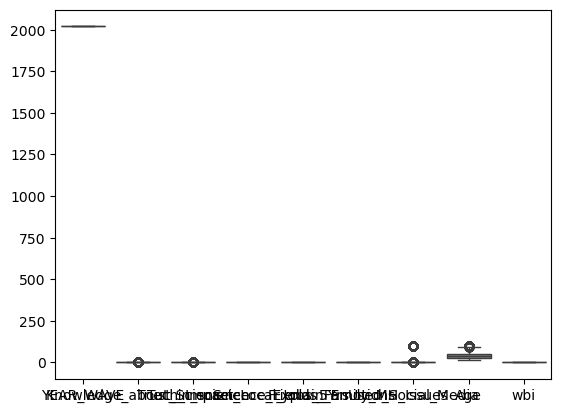

In [ ]:
sns.boxplot(data = df2.select_dtypes(include = ['int64' , 'float64']))    #WITH DF2
plt.show()

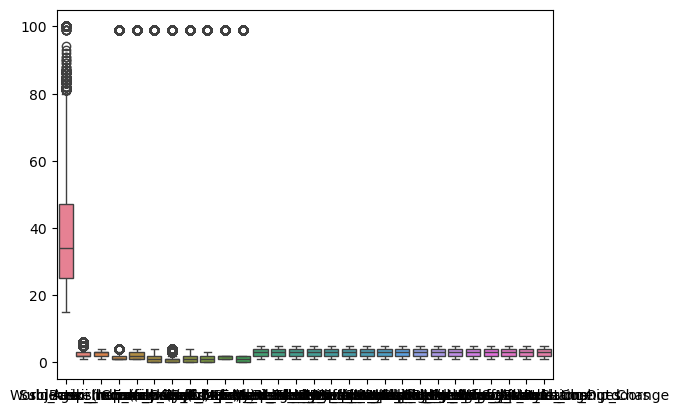

<Figure size 10000x10000 with 0 Axes>

In [ ]:
sns.boxplot(data = df1.select_dtypes(include = ['int64' , 'float64']))    #WITH DF1
plt.figure(figsize=(100 , 100))

plt.show()

# HEATMAPS

<Axes: >

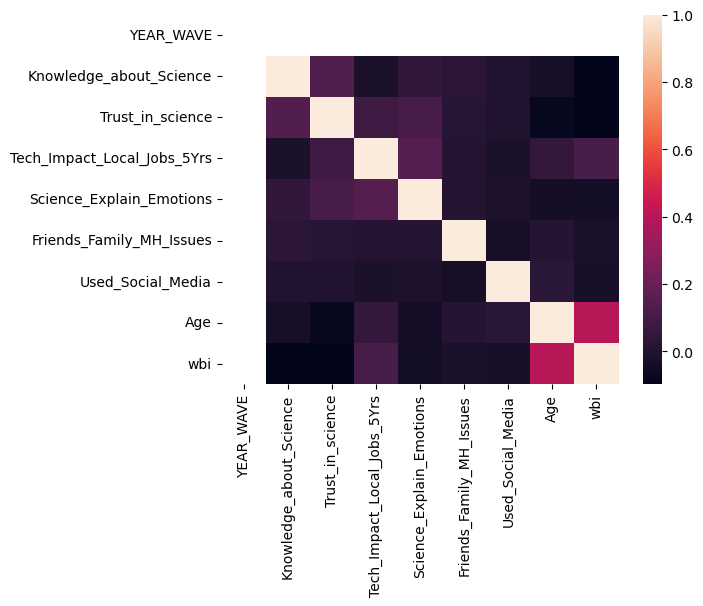

In [ ]:
sns.heatmap(df2.corr(numeric_only = True))       #WITH DF2

<Axes: >

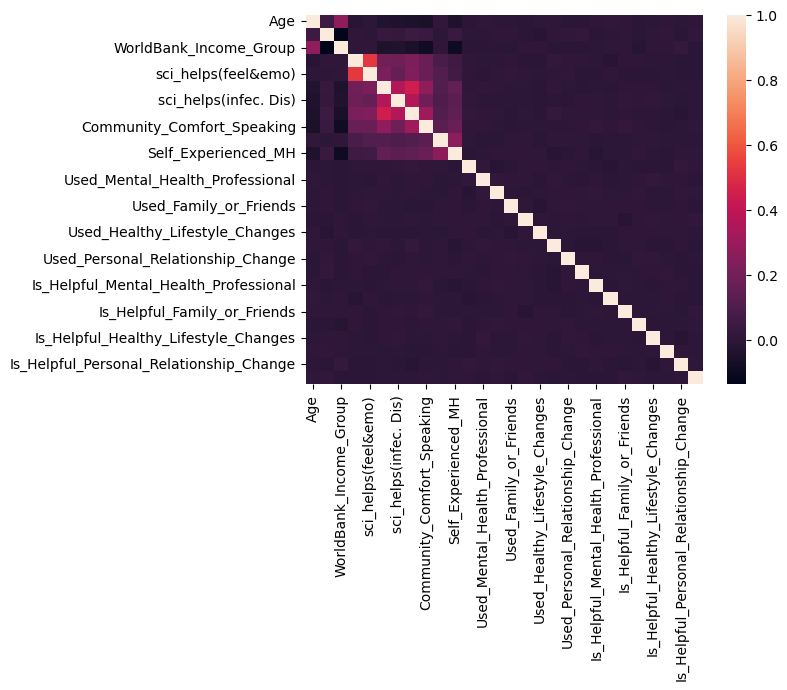

In [ ]:
sns.heatmap(df1.corr(numeric_only = True))     #WITH DF1

# OUTLIERS ANALYSIS

In [ ]:
num_cols = df1.select_dtypes(exclude = 'object')     #WITH DF1

In [ ]:
# Function to removce outlier from multiple columns
def remove_outliers_iqr_multi(df1, columns):
    df_clean = df1.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    for col in columns:
        sns.boxplot(y=df_clean[col])
        plt.title(f'Boxplot of {col} (Outliers Removed)')
        plt.show()
    return df_clean

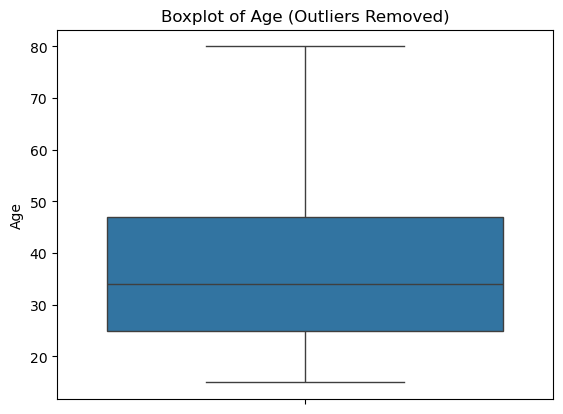

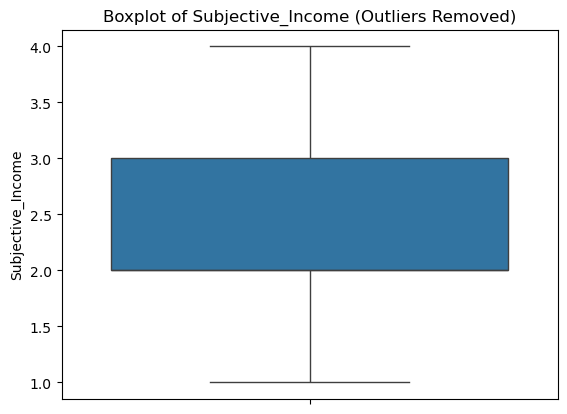

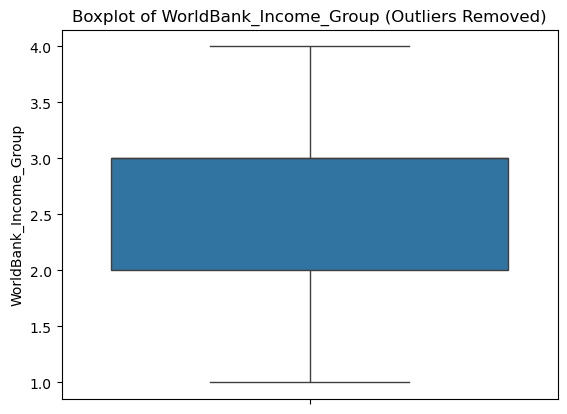

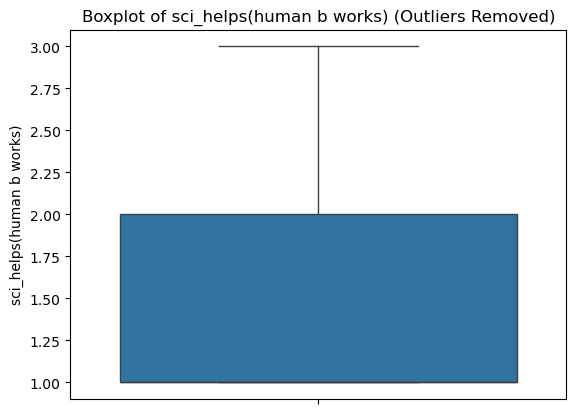

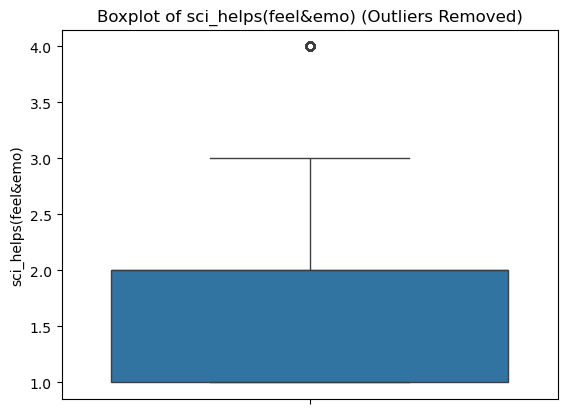

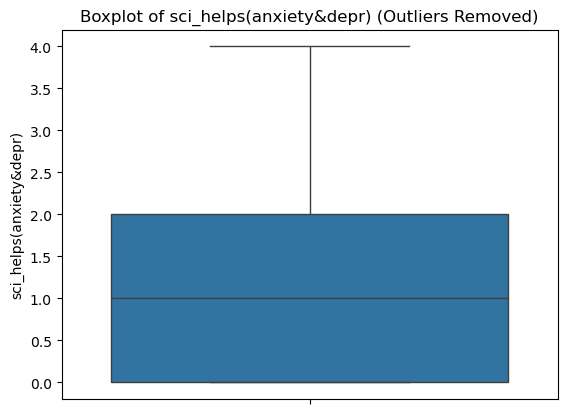

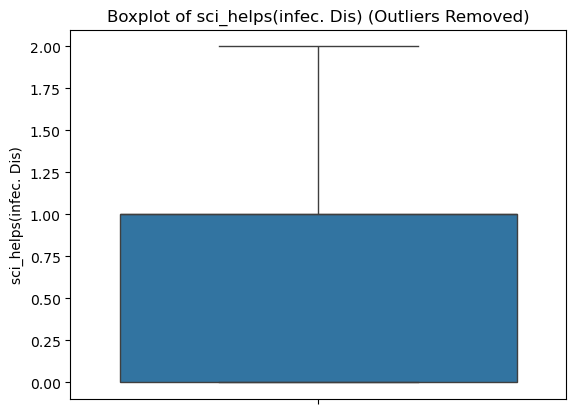

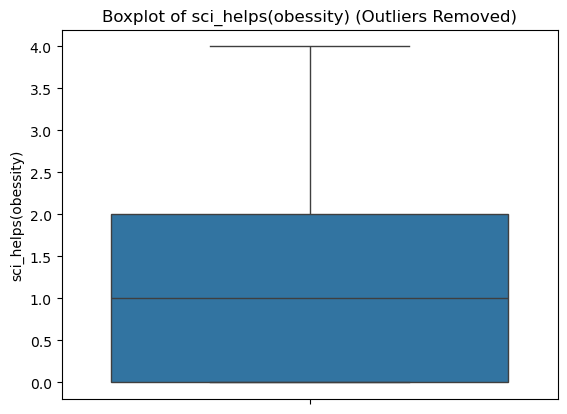

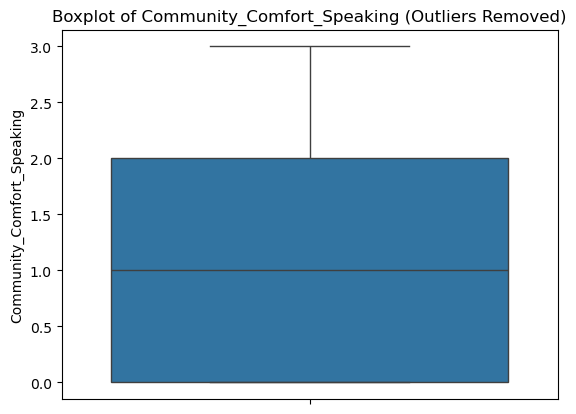

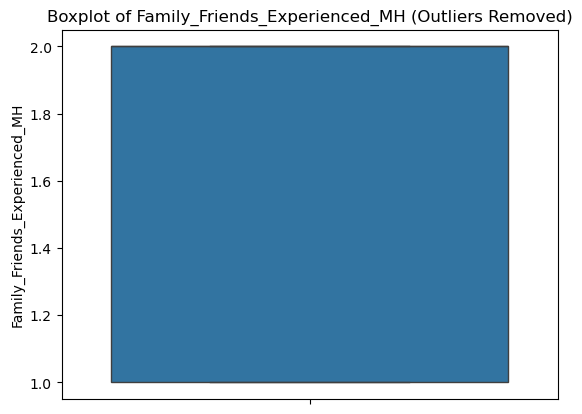

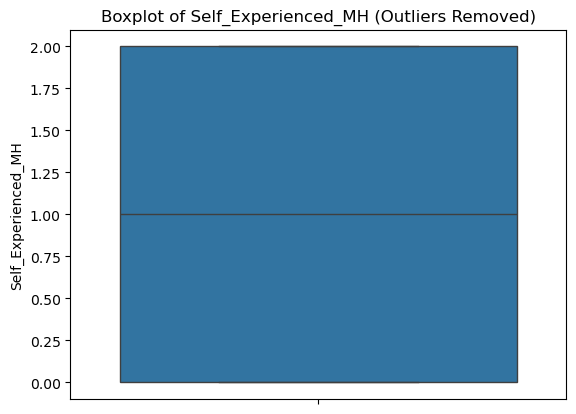

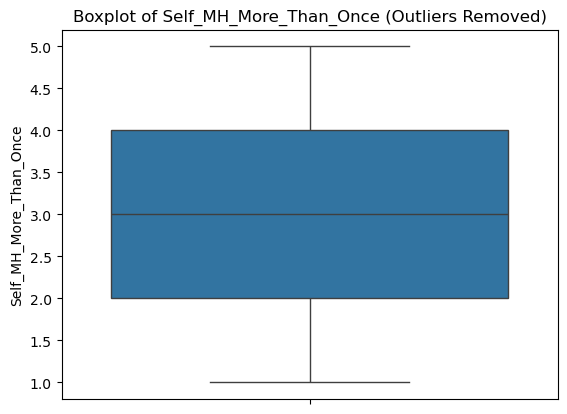

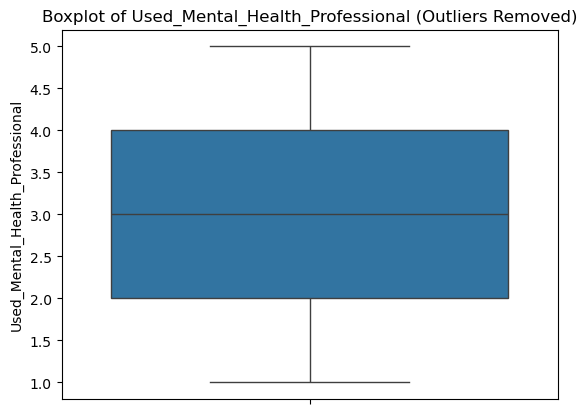

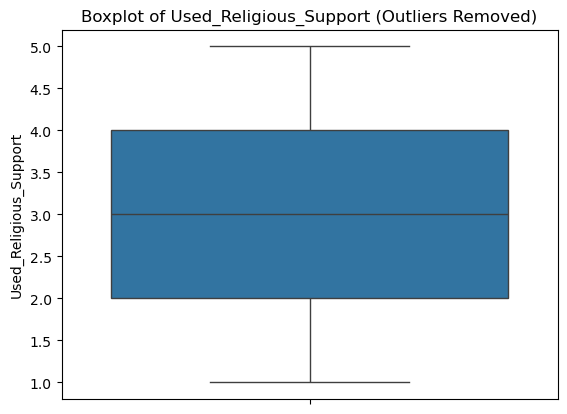

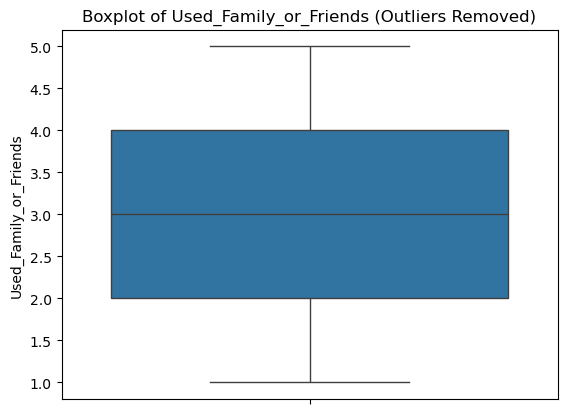

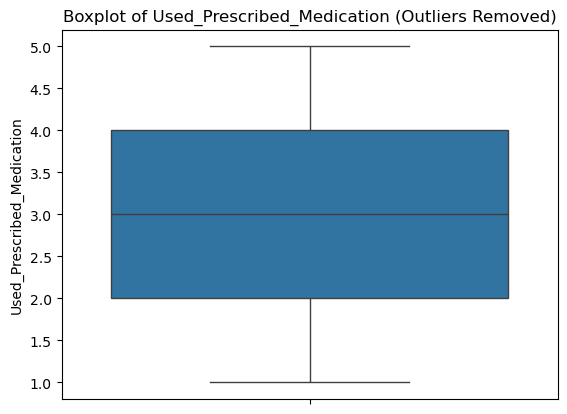

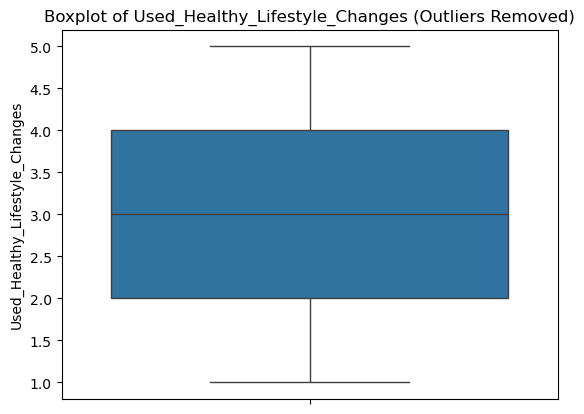

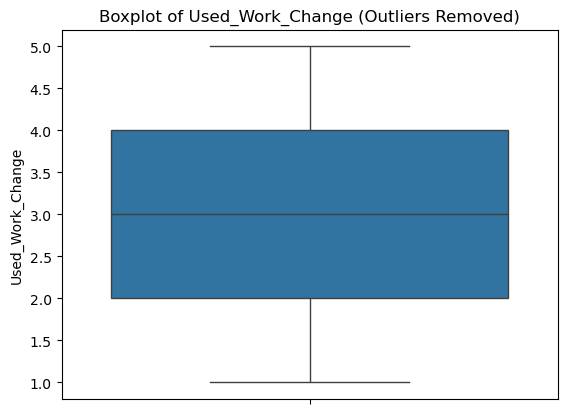

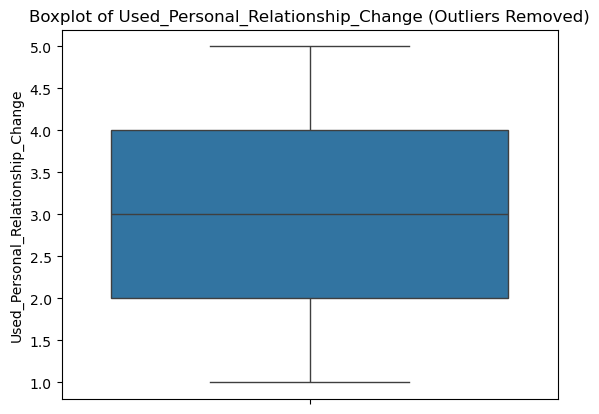

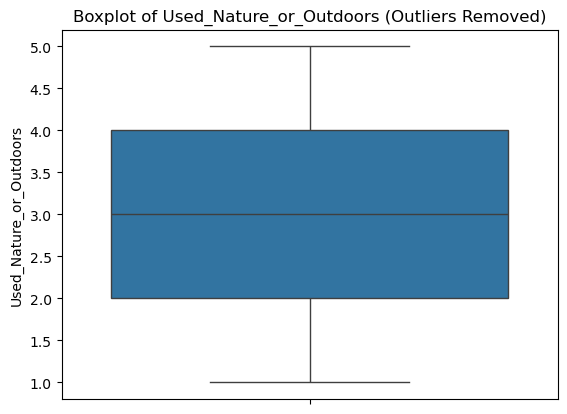

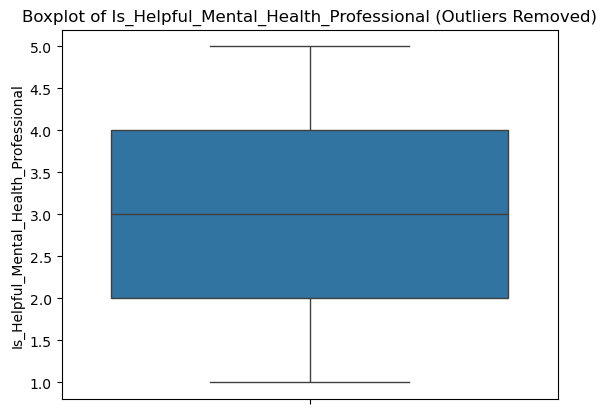

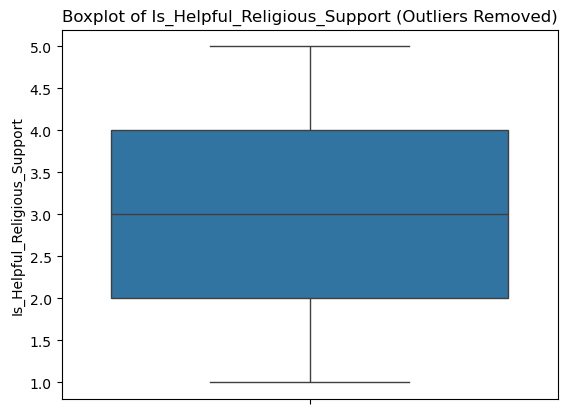

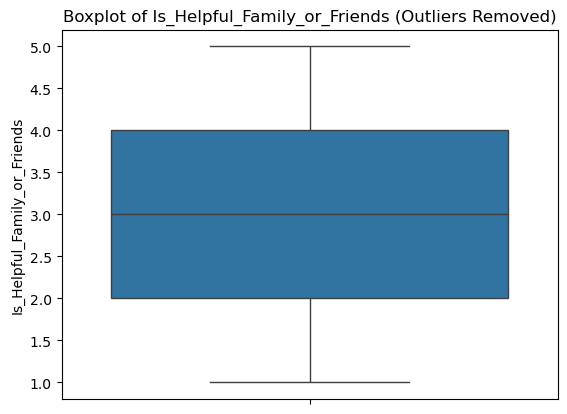

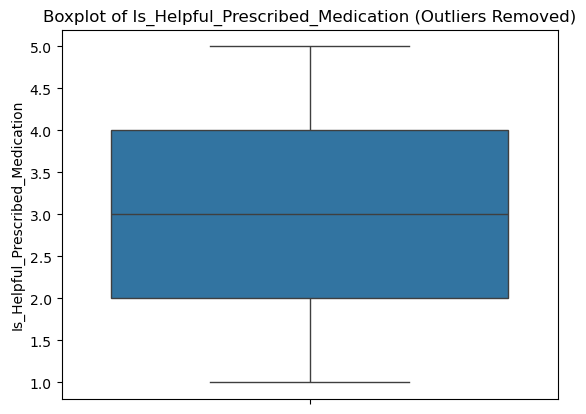

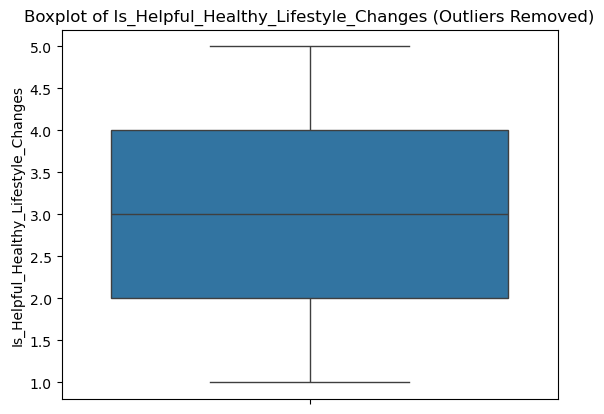

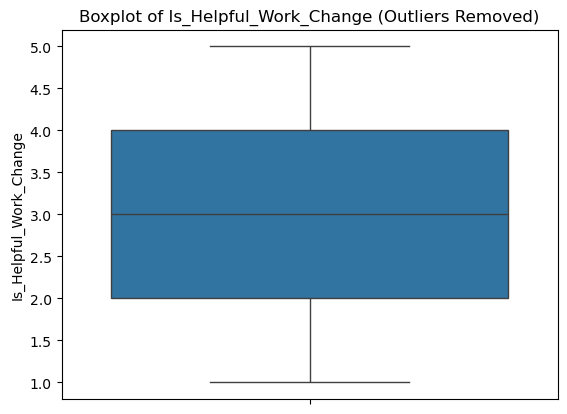

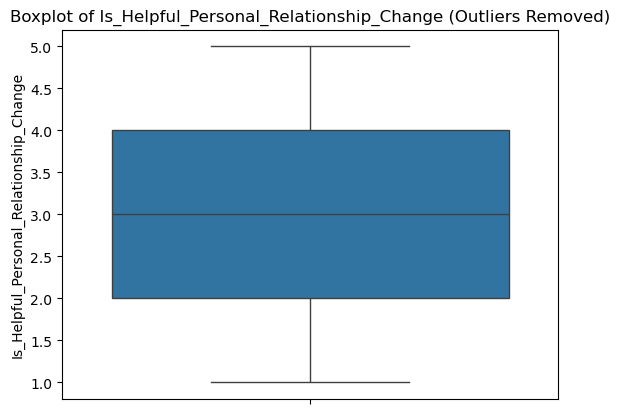

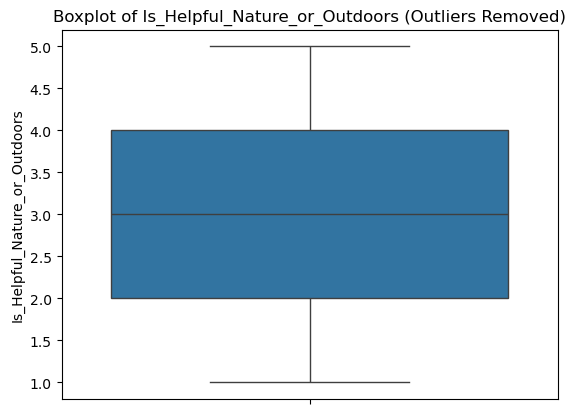

In [ ]:
df1 = remove_outliers_iqr_multi(df1, num_cols)

In [ ]:
num_cols = df2.select_dtypes(exclude = 'object')     #WITH DF2

In [ ]:
# Function to removce outlier from multiple columns
def remove_outliers_iqr_multi(df2, columns):
    df_clean = df2.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    for col in columns:
        sns.boxplot(y=df_clean[col])
        plt.title(f'Boxplot of {col} (Outliers Removed)')
        plt.show()
    return df_clean

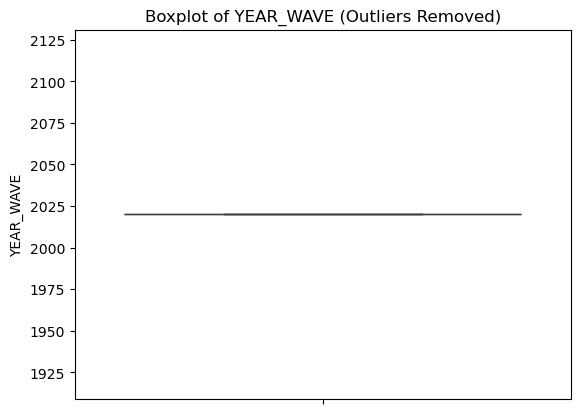

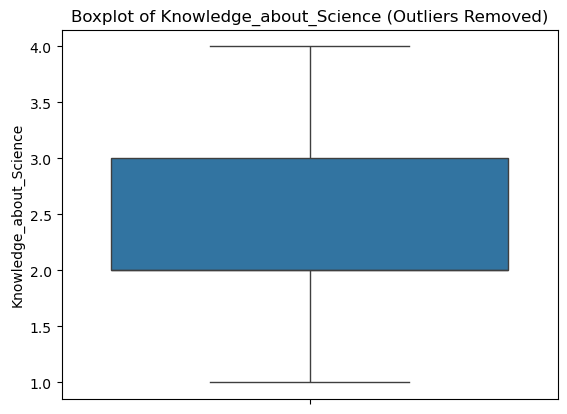

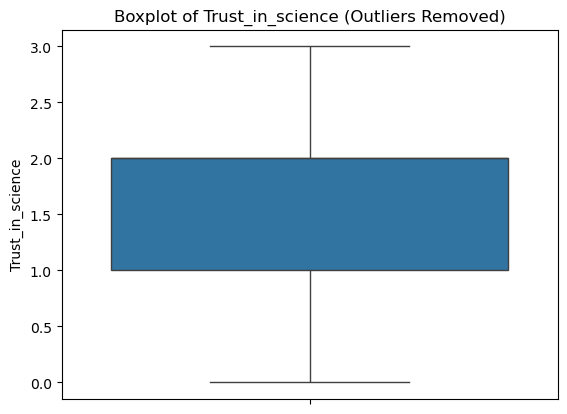

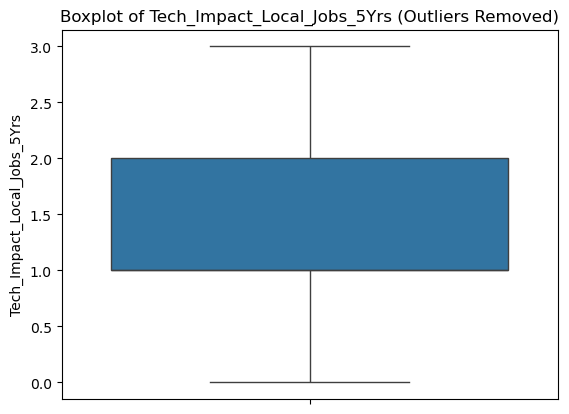

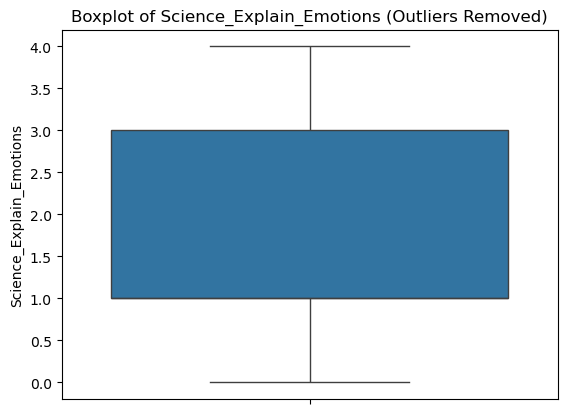

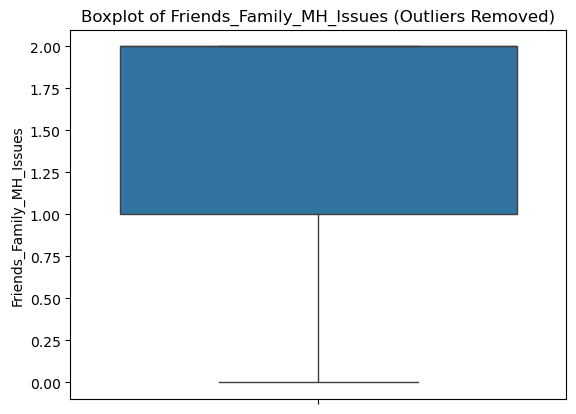

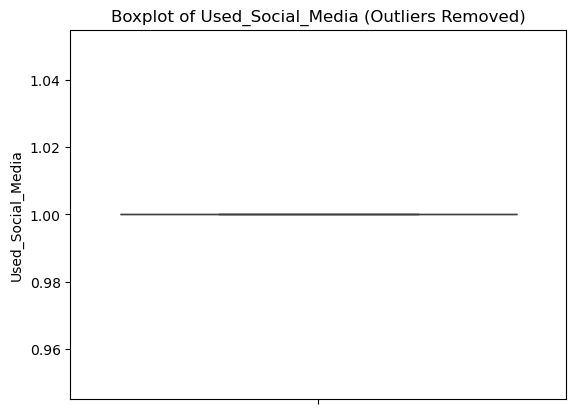

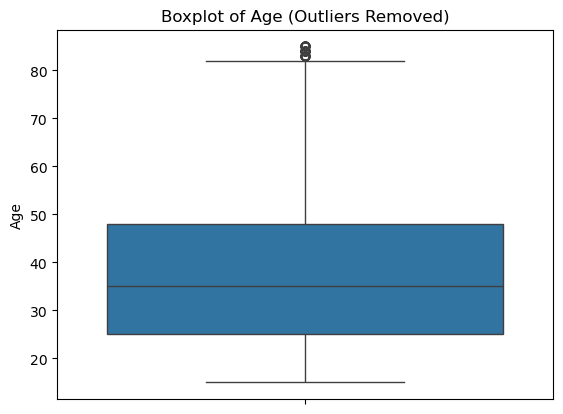

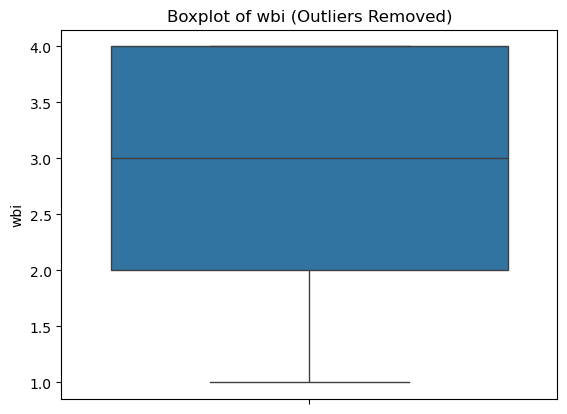

In [ ]:
df2 = remove_outliers_iqr_multi(df2, num_cols)

# LINEAR REGRESSION IN DATA FRAME

In [ ]:
df1.shape

(15129, 32)

In [ ]:
df2.shape

(93558, 33)

## label encoder

In [ ]:
from sklearn.preprocessing import LabelEncoder        #WITH DF1
le=LabelEncoder()

cat_cols = df1.select_dtypes(include=['object']).columns

for col in cat_cols:
    df1[col]=le.fit_transform(df1[col])

TypeError: Encoders require their input argument must be uniformly strings or numbers. Got ['int', 'str']

In [ ]:
df1.head()

,COUNTRYNAME,Gender,Age,Household_Income,Subjective_Income,WorldBank_Income_Group,sci_helps(human b works),sci_helps(feel&emo),sci_helps(anxiety&depr),sci_helps(infec. Dis),...,Used_Personal_Relationship_Change,Used_Nature_or_Outdoors,Is_Helpful_Mental_Health_Professional,Is_Helpful_Religious_Support,Is_Helpful_Family_or_Friends,Is_Helpful_Prescribed_Medication,Is_Helpful_Healthy_Lifestyle_Changes,Is_Helpful_Work_Change,Is_Helpful_Personal_Relationship_Change,Is_Helpful_Nature_or_Outdoors
0,8,0,62,4,3,3,1,2,2,1,...,3,3,3,1,4,5,2,1,1,5
2,8,0,38,4,2,3,1,2,3,1,...,1,2,5,1,4,2,3,4,1,5
3,8,1,62,1,3,3,3,4,1,1,...,5,1,4,3,1,4,5,4,4,3
4,8,1,25,4,2,3,1,1,2,1,...,3,5,1,1,5,5,2,1,2,1
5,8,1,37,5,4,3,2,2,1,1,...,4,4,3,1,2,5,5,3,5,4
